# 🔬 Dual-Fuel Engine NOx Analysis
This project investigates the key drivers of NOx emissions in a dual-fuel engine dataset, evaluating whether complex machine learning models provide additional predictive value over simple physical relationships.

## 🎯 Objective

The aim of this analysis is to:
- Identify the primary factors influencing NOx emissions
- Compare linear, regularised, and tree-based models
- Assess whether model complexity improves predictive performance
- Evaluate the validity and limitations of the dataset

In [1]:
# libraries needed
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## 📥 Data Loading and Initial Checks

The dataset is loaded from a local directory and basic validation checks are performed to ensure data integrity.

In [2]:
# paths + load
# --- Folders ---
DATA_DIR = Path("data_in")
OUT_DIR  = Path("analytics_out")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- load data---
DATA_PATH = DATA_DIR / "dual_fuel_engine_dataset.csv"

df = pd.read_csv(DATA_PATH)

print(f"Loaded: {DATA_PATH.name}")

# --- sanity checks ---
if df.empty:
    raise ValueError("Dataset is empty")

if df.isna().all().all():
    raise ValueError("Dataset contains only NaNs")

print(df.shape)
df.head()
df.info()
df.describe()

Loaded: dual_fuel_engine_dataset.csv
(1463, 19)
<class 'pandas.DataFrame'>
RangeIndex: 1463 entries, 0 to 1462
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Engine_Load_Percent                 1463 non-null   int64  
 1   Diesel_Energy_Share                 1463 non-null   float64
 2   Injection_Timing                    1463 non-null   float64
 3   Fuel_Injection_Pressure             1463 non-null   float64
 4   EGR_Rate                            1463 non-null   float64
 5   Boost_Pressure                      1463 non-null   float64
 6   Intake_Temperature                  1463 non-null   float64
 7   Equivalence_Ratio                   1463 non-null   float64
 8   Cylinder_Pressure_Peak              1463 non-null   float64
 9   Combustion_Duration                 1463 non-null   float64
 10  Gasoline_Energy_Share               1463 non-null   float64
 11  Combus

,Engine_Load_Percent,Diesel_Energy_Share,Injection_Timing,Fuel_Injection_Pressure,EGR_Rate,Boost_Pressure,Intake_Temperature,Equivalence_Ratio,Cylinder_Pressure_Peak,Combustion_Duration,Gasoline_Energy_Share,BSFC,NOx_Emissions,Soot_Emissions,CO_Emissions,Gross_Indicated_Thermal_Efficiency,Combustion_Stability_Index,Target_Score
count,1463.000000,1463.000000,1463.000000,1463.00000,1463.000000,1463.000000,1463.000000,1463.000000,1463.000000,1463.000000,1463.000000,1463.000000,1463.000000,1463.000000,1463.000000,1463.000000,1463.000000,1463.000000
mean,54.511278,55.033903,-14.537867,1146.60704,15.022488,2.494046,329.555161,0.956036,95.027068,34.685714,44.966097,239.007382,1.143869,1.761210,0.797430,45.361360,0.849576,10.025673
std,32.957042,14.101444,5.822964,381.60771,8.501780,0.569818,17.227479,0.142456,14.414446,8.526585,14.101444,8.351361,0.383283,0.713118,0.400017,3.644535,0.088027,2.245818
min,10.000000,30.070000,-25.000000,501.30000,0.000000,1.500000,300.000000,0.700000,70.000000,20.000000,20.000000,212.600000,0.400000,0.500000,0.100000,36.570000,0.700000,5.690000
25%,25.000000,43.295000,-19.700000,809.95000,7.800000,2.005000,314.850000,0.830000,82.750000,27.400000,33.115000,232.600000,0.800000,1.140000,0.460000,42.460000,0.770000,8.440000
50%,50.000000,55.120000,-14.000000,1127.10000,15.000000,2.500000,329.600000,0.960000,94.600000,34.400000,44.880000,239.300000,1.130000,1.780000,0.780000,45.310000,0.850000,9.610000
75%,75.000000,66.885000,-9.300000,1489.15000,22.250000,2.970000,344.150000,1.080000,107.600000,41.800000,56.705000,245.500000,1.490000,2.390000,1.150000,48.270000,0.930000,11.240000
max,100.000000,80.000000,-5.000000,1798.80000,29.900000,3.500000,360.000000,1.200000,119.900000,50.000000,69.930000,263.900000,1.860000,3.000000,1.500000,55.600000,1.000000,20.280000


## 📊 Data Overview

The dataset contains engine operating parameters, fuel composition variables, and resulting emissions outputs.

Key variables include:
- Fuel injection pressure
- Engine load
- EGR rate
- NOx, soot, and CO emissions
- Thermal efficiency and BSFC

## 🧪 Data Quality Assessment

Initial checks confirm:
- No missing values
- No duplicate records
- Consistent numerical formatting

However, no units are explicitly provided, and assumptions are made based on typical engine data ranges.

In [3]:
# --- data audit ---

print("Missing values:\n", df.isna().sum())
print("\nDuplicates:", df.duplicated().sum())
print("\nUnique values:\n", df.nunique())

Missing values:
 Engine_Load_Percent                   0
Diesel_Energy_Share                   0
Injection_Timing                      0
Fuel_Injection_Pressure               0
EGR_Rate                              0
Boost_Pressure                        0
Intake_Temperature                    0
Equivalence_Ratio                     0
Cylinder_Pressure_Peak                0
Combustion_Duration                   0
Gasoline_Energy_Share                 0
Combustion_Mode                       0
BSFC                                  0
NOx_Emissions                         0
Soot_Emissions                        0
CO_Emissions                          0
Gross_Indicated_Thermal_Efficiency    0
Combustion_Stability_Index            0
Target_Score                          0
dtype: int64

Duplicates: 0

Unique values:
 Engine_Load_Percent                      5
Diesel_Energy_Share                   1266
Injection_Timing                       201
Fuel_Injection_Pressure               1373
EGR_Ra

## 🔍 Exploratory Data Analysis

Correlation analysis and scatter plots were used to identify relationships between engine parameters and emissions.
A near-perfect linear relationship is observed between fuel injection pressure and NOx emissions.

In contrast, expected physical relationships (e.g. inverse effect of EGR on NOx) are not present, suggesting simplified or synthetic dataset behaviour.

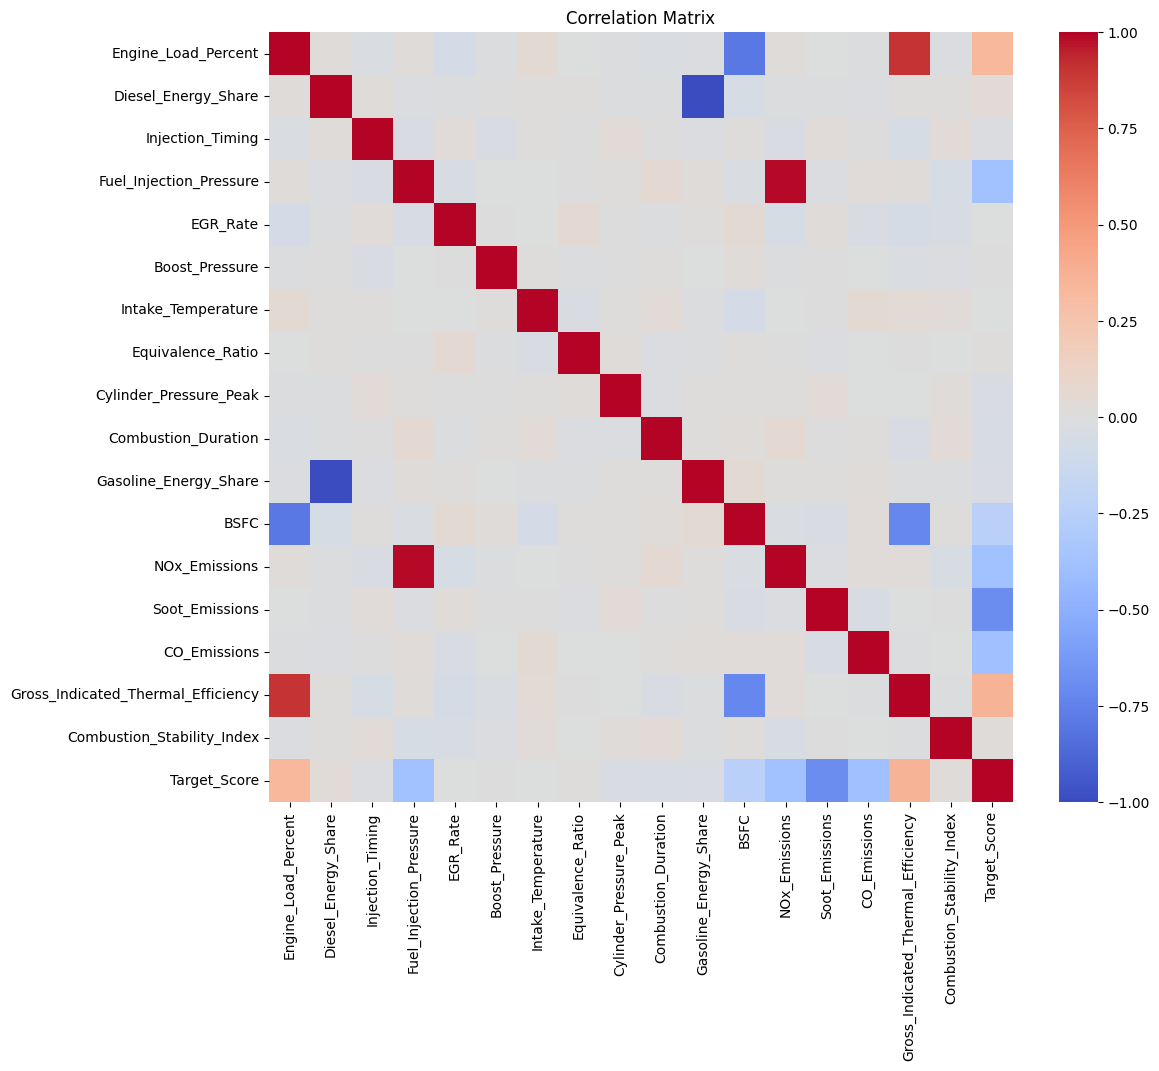

In [4]:
# --- quick correlations ---

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

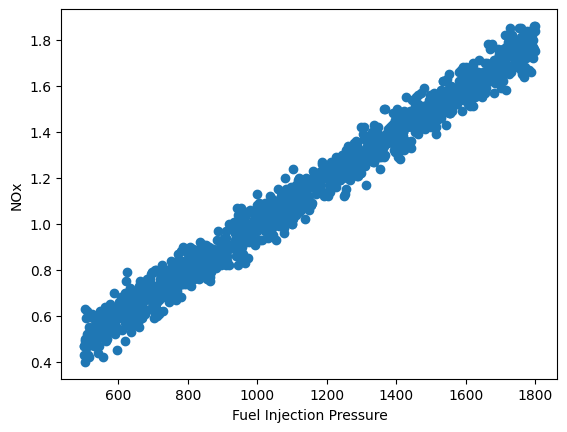

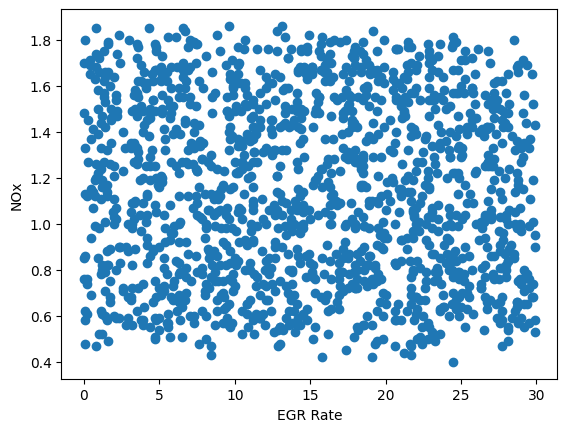

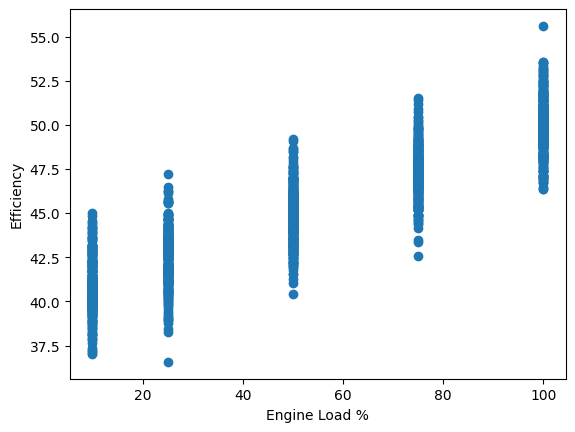

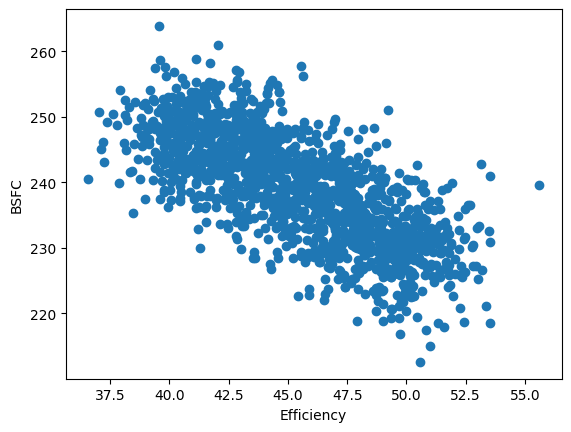

In [5]:
# NOx vs key drivers
plt.scatter(df['Fuel_Injection_Pressure'], df['NOx_Emissions'])
plt.xlabel("Fuel Injection Pressure")
plt.ylabel("NOx")
plt.show()

plt.scatter(df['EGR_Rate'], df['NOx_Emissions'])
plt.xlabel("EGR Rate")
plt.ylabel("NOx")
plt.show()

# Efficiency vs load
plt.scatter(df['Engine_Load_Percent'], df['Gross_Indicated_Thermal_Efficiency'])
plt.xlabel("Engine Load %")
plt.ylabel("Efficiency")
plt.show()

# BSFC vs efficiency
plt.scatter(df['Gross_Indicated_Thermal_Efficiency'], df['BSFC'])
plt.xlabel("Efficiency")
plt.ylabel("BSFC")
plt.show()

## 🤖 Model Development

Three models were evaluated:
- Linear Regression
- Ridge Regression
- Random Forest Regressor

All models were assessed using 5-fold cross-validation.

In [ ]:
#Step 1 — Define target
y = df['NOx_Emissions']

#Step 2 — Define features
X = df.drop(columns=[
    'NOx_Emissions',
    'Soot_Emissions',
    'CO_Emissions',
    'Target_Score'
])

#handle categorical
X=pd.get_dummies(X, drop_first=True)
#build pipeline which includes scaling so coefficeints are directly comparable in magnitude
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

pipeline= Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

#cross validation (no manual split)
from sklearn.model_selection import cross_val_score
scores= cross_val_score(pipeline, X, y, cv=5, scoring='r2')
print("CV mean:", scores.mean())
print("CV std:", scores.std())

CV mean: 0.9830605563575725
CV std: 0.0008755527605811226


In [7]:
#model interpretation
#fit ipeline on full data
pipeline.fit(X,y)
#get model
model=pipeline.named_steps['model']
#get feature names
feature_names=X.columns
#get coefficients
coeffs=model.coef_
#put into a dataframe
import pandas as pd
#create a table and sort values so most influential at top
coef_df=pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coeffs
}).sort_values(by='Coefficient', key=abs, ascending =False)

print(coef_df.head(10))

                               Feature  Coefficient
3              Fuel_Injection_Pressure     0.379985
0                  Engine_Load_Percent     0.003253
4                             EGR_Rate    -0.003034
7                    Equivalence_Ratio     0.002351
11                                BSFC     0.001866
13          Combustion_Stability_Index     0.001771
15                Combustion_Mode_RCCI     0.001566
5                       Boost_Pressure    -0.001325
12  Gross_Indicated_Thermal_Efficiency    -0.001173
1                  Diesel_Energy_Share     0.001057


In [8]:
#model comparison
#ridge
from sklearn.linear_model import Ridge
pipeline_ridge = Pipeline([
    ('scalar', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])
scores_ridge=cross_val_score(pipeline_ridge, X, y, cv=5, scoring ='r2')
print("Ridge CV mean:", scores_ridge.mean())
print("Ridge CV std:", scores_ridge.std())

Ridge CV mean: 0.98306141453116
Ridge CV std: 0.0008821978826200329


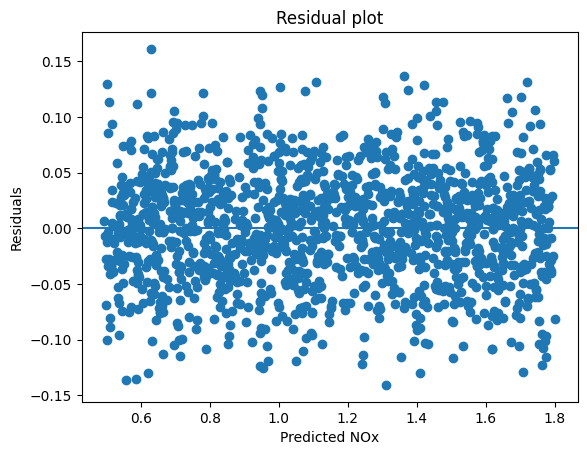

In [ ]:
#do we trust it?
#step 1 residuals: looking for ideal which has random scatter centred around 0, its a bad sign if theres a curve(nonlinearity)/pattern (missing something)/funnel shape (heteroscedasticity)
y_pred=pipeline.predict(X)
residuals=y-y_pred
#step 2 residual plot
import matplotlib.pyplot as plt
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted NOx")
plt.ylabel("Residuals")
plt.title("Residual plot")
plt.show()

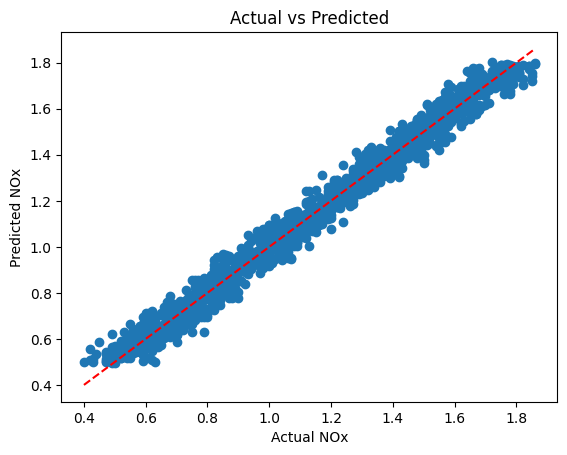

In [ ]:
#step3 actual vs predicted: good= points on diagonal line
plt.scatter(y, y_pred)
plt.xlabel("Actual NOx")
plt.ylabel("Predicted NOx")
plt.title("Actual vs Predicted")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.show()



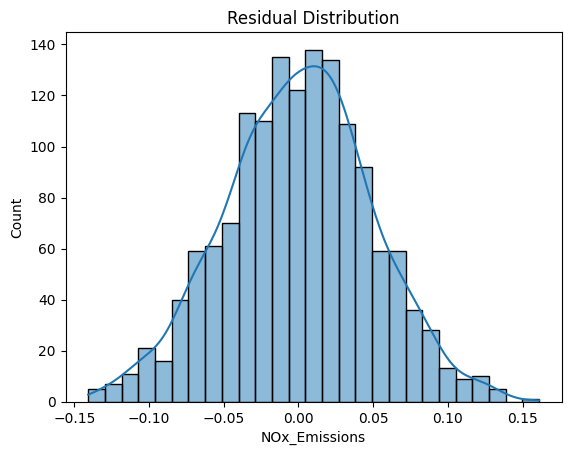

In [ ]:
# Step 4 — Error distribution: good= roughly normal distribution centred at 0
import seaborn as sns

sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()


In [13]:
#tried ridge above, now try tree-based model
from sklearn.ensemble import RandomForestRegressor
pipeline_rf=Pipeline([
    ('model', RandomForestRegressor(random_state=42))
])
scores_rf=cross_val_score(pipeline_rf, X, y, cv=5, scoring='r2')

print("RF mean:", scores_rf.mean())
print("RF std:", scores_rf.std())


RF mean: 0.9808733728030485
RF std: 0.0015872291455301614


In [19]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

X_simple=df[['Fuel_Injection_Pressure']]
y=df['NOx_Emissions']
pipeline_simple=Pipeline([
    ('model', LinearRegression())
])
scores_simple=cross_val_score(pipeline_simple, X_simple, y, cv=5, scoring='r2')
print("Single feature R2:", scores_simple.mean())
print("Single feature std:",scores_simple.std())

Single feature R2: 0.9833542294716136
Single feature std: 0.0010208623666988616


All models achieve similarly high performance (R² ≈ 0.98), indicating that model choice has minimal impact.

This suggests that the dataset is dominated by a simple underlying relationship rather than complex interactions.

## 🧠 Model Simplification

A single-feature model using only fuel injection pressure was evaluated.

In [22]:
#create a results table to compare all models
results = []
results.append({
    'Model': 'Linear (all features)',
    'CV Mean R2': scores.mean(),
    'CV Std': scores.std()
})
results.append({
    'Model': 'Ridge',
    'CV Mean R2': scores_ridge.mean(),
    'CV Std': scores_ridge.std()
})
results.append({
    'Model': 'Random Forest',
    'CV Mean R2': scores_rf.mean(),
    'CV Std': scores_rf.std()
})
results.append({
    'Model': 'Linear (Injection Pressure only)',
    'CV Mean R2': scores_simple.mean(),
    'CV Std': scores_simple.std()
})
results_df = pd.DataFrame(results)
results_df= results_df.sort_values(by='CV Mean R2', ascending=False)
results_df

,Model,CV Mean R2,CV Std
3,Linear (Injection Pressure only),0.983354,0.001021
1,Ridge,0.983061,0.000882
0,Linear (all features),0.983061,0.000876
2,Random Forest,0.980873,0.001587


The single-variable model achieves equivalent performance to multi-feature models, confirming that predictive power is almost entirely driven by fuel injection pressure.

## ⚠️ Limitations

- Lack of expected physical relationships (e.g. EGR vs NOx)
- Highly deterministic behaviour
- Limited noise and interaction effects
- Likely synthetic or simplified dataset

These factors limit the generalisability of the model to real-world engine systems.

## ✅ Conclusion

This analysis demonstrates that:
- NOx emissions are strongly driven by fuel injection pressure
- Model complexity does not improve performance
- Dataset simplicity dominates predictive results

The project highlights the importance of validating dataset realism before interpreting model performance.